In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# This line loads your file into a variable called 'df' (short for DataFrame)
df = pd.read_csv('heart.csv')

# This line shows us the first 5 rows to confirm everything is perfect
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
# 1. See the size of the dataset
print("Dataset Shape:", df.shape)

# 2. Check for missing values and data types
print("\n--- Dataset Information ---")
df.info()

# 3. Check for exact null counts
print("\n--- Null Values per Column ---")
print(df.isnull().sum())

Dataset Shape: (303, 14)

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

--- Null Values per Column ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak

In [7]:
# This gives us mean, standard deviation, min, max, and percentiles for every column
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


C:\Users\HP\AppData\Local\Temp\ipykernel_3772\1711880595.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='magma')


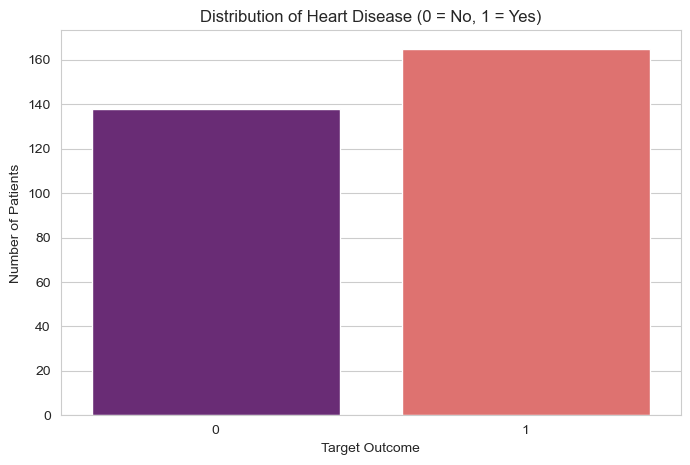

In [8]:
# Set the style of the graphs
sns.set_style("whitegrid")

# Create a count plot for the 'target' column
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df, palette='magma')

# Adding labels
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)')
plt.xlabel('Target Outcome')
plt.ylabel('Number of Patients')

# Show the plot
plt.show()

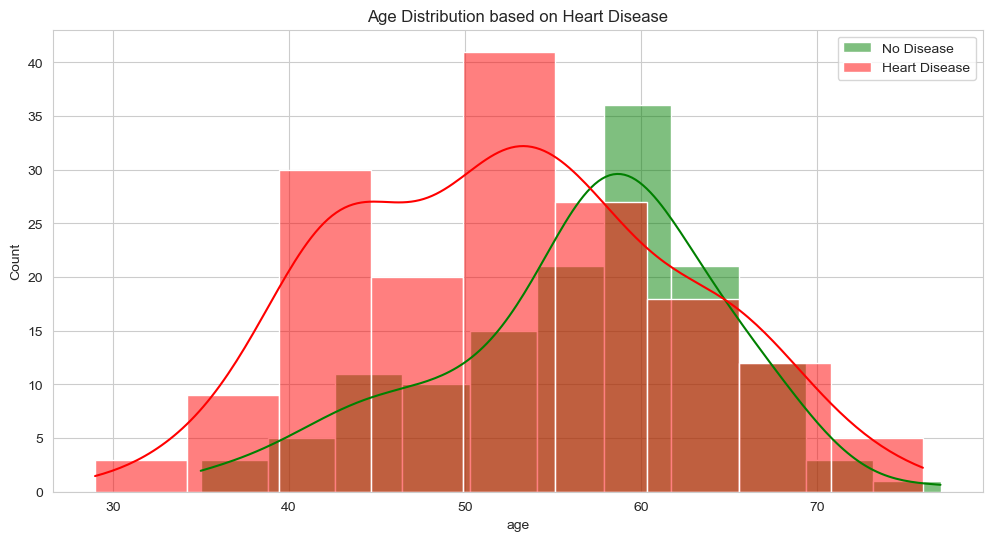

In [9]:
plt.figure(figsize=(12, 6))

# Plotting age distribution for people WITH and WITHOUT heart disease
sns.histplot(df[df['target'] == 0]['age'], color='green', label='No Disease', kde=True)
sns.histplot(df[df['target'] == 1]['age'], color='red', label='Heart Disease', kde=True)

plt.title('Age Distribution based on Heart Disease')
plt.legend()
plt.show()

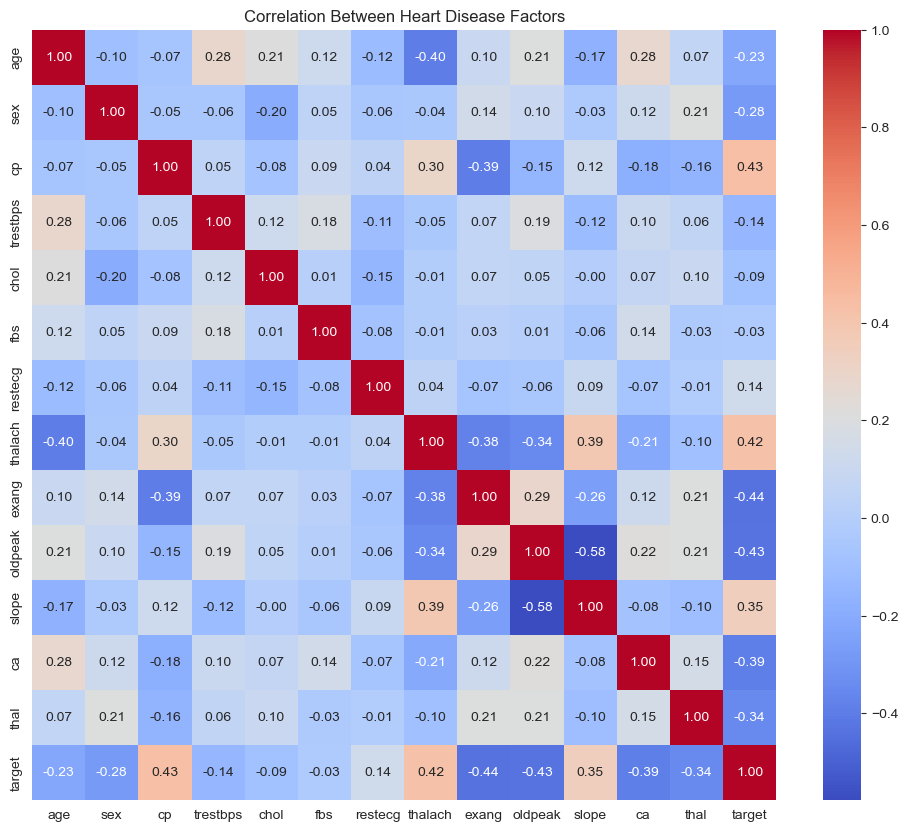

In [10]:
plt.figure(figsize=(12,10))

# This calculates how much each column relates to the other
correlation = df.corr()

# We use a heatmap to make the numbers easy to see with colors
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Between Heart Disease Factors")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

# 1. Define 'X' (Features/Inputs) and 'y' (Target/Output)
# We drop 'target' from X because the model shouldn't see the answer!
X = df.drop('target', axis=1) 
y = df['target']

# 2. Split the data
# test_size=0.2 means 80% data for training and 20% for testing
# random_state=42 ensures we get the same results every time we run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Split Successfully!")
print(f"Total rows: {len(df)}")
print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Data Split Successfully!
Total rows: 303
Training rows: 242
Testing rows: 61


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Initialize the model
model = LogisticRegression(max_iter=1000)

# 2. Train the model (This is where the 'learning' happens)
model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred = model.predict(X_test)

# 4. Check the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 88.52%


In [13]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize the Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)

# 2. Train the model
tree_model.fit(X_train, y_train)

# 3. Make predictions
tree_pred = tree_model.predict(X_test)

# 4. Check accuracy
tree_accuracy = accuracy_score(y_test, tree_pred)
print(f"Decision Tree Accuracy: {tree_accuracy * 100:.2f}%")

Decision Tree Accuracy: 75.41%


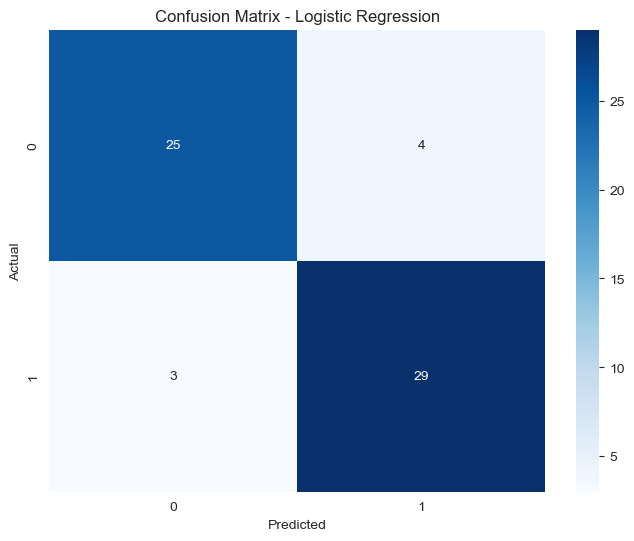

In [14]:
from sklearn.metrics import confusion_matrix

# Create the matrix for our best model (Logistic Regression)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [15]:
# 1. We create a copy of our test data
presentation_data = X_test.copy()

# 2. We add the 'Actual' results and our 'Predicted' results to it
presentation_data['Actual_Health_Status'] = y_test
presentation_data['Predicted_Health_Status'] = y_pred

# 3. Let's make the numbers readable for Power BI
# Changing 0 to "Healthy" and 1 to "Heart Disease"
presentation_data['Actual_Health_Status'] = presentation_data['Actual_Health_Status'].replace({0: 'Healthy', 1: 'Heart Disease'})
presentation_data['Predicted_Health_Status'] = presentation_data['Predicted_Health_Status'].replace({0: 'Healthy', 1: 'Heart Disease'})

# 4. Save this to a new CSV file
presentation_data.to_csv('heart_disease_final_results.csv', index=False)

print("Final CSV for Power BI saved as 'heart_disease_final_results.csv'!")

Final CSV for Power BI saved as 'heart_disease_final_results.csv'!


In [16]:
df.shape

(303, 14)